<div style="text-align: center; font-family: Arial, sans-serif; margin-top: 50px;">
<h1 style="font-size: 36px; font-weight: bold; color: #4CAF50;">Mini-projet X - Méthode Monte Carlo</h1>
<h2 style="font-size: 20px; font-weight: bold; color: #4CAF50;">PHS3903</h2>
<h2 style="font-size: 20px; margin-bottom: 20px;">[Larose, Simon ; Gauthier, Émile ; Brunet-Mercier, Mathile]</h2>
<h2 style="font-size: 16px; margin-bottom: 10px;">[2256873; 2267504; 2293569]</h2>
<h2 style="font-size: 16px; margin-bottom: 10px;">[11/02/2026]</h2>
<h2 style="font-size: 16px; margin-bottom: 10px;">[Maksim Skorobagatiy; Jérémie Villeneuve; Sean Molesky]</h2>
</div>


### Calcul du volume d'une $N$-sphère (20 points)

### Introduction
Une $N$-sphère de rayon $R$ est définie comme l'ensemble des points situés à une distance inférieure ou égale à $R$ de l'origine dans un espace à $N$ dimensions. Si on utilise les coordonnées cartésiennes $(x_1, x_2, \dots, x_N)$ pour décrire un point, alors ce point est situé à l'intérieur de la $N$-sphère si le critère suivant est respecté :

$$
\sum_{i=1}^{N} x_i^2 \leq R^2, \quad N=1,2,\dots
$$

Voici quelques exemples de $N$-sphères afin de clarifier ce concept :
* Une 3-sphère est la sphère habituelle en trois dimensions. Son volume est la boule dont la sphère est le contour.
* Une 2-sphère est un cercle. Son volume est l'aire du disque circonscrit par le cercle.
* Une 1-sphère est formée de deux points sur une droite qui sont situés à égale distance de l'origine. Son volume est défini comme la longueur du segment.

Ce concept peut sembler abstrait, mais il apparaît naturellement en physique statistique quand on travaille dans l'espace de phase pour étudier les propriétés d'un ensemble de $N$ particules avec une énergie fixe (ex. : gaz idéal dans une boîte fermée). 

Dans ce mini-devoir, on vous demande de calculer le volume d'une $N$-sphère de rayon unitaire $R=1$ à l'aide de la méthode de Monte-Carlo vue en classe pour le calcul d'intégrales. Le résultat est déjà connu, à savoir :

$$
V_N = \frac{\pi^{N/2}}{\Gamma\left(\frac{N}{2} + 1\right)},
$$
où $\Gamma(x)$ est la fonction gamma, ce qui vous permettra de calculer l'erreur afin d'analyser le comportement de l'algorithme.

### Choix de la méthode de Monte-Carlo

**a) [4 pts]** Expliquer pourquoi les méthodes de Monte Carlo pour l'intégration sont avantageuses pour le calcul d'intégrales à $N$ dimensions lorsque $N$ devient grand.

### Réponse a):

Soit une intégrale en N dimensions à approximer numériquement :

$$
    V_N = \int f(x_1,x_2, ...,x_N) dx_1 dx_2...dx_N.
    
$$

La méthode de Monte-Carlo consiste à générer aléatoirement \(N_{\text{tot}}\) points dans une région de volume \(V_{\text{tot}}\). L'intégrale \eqref{eq:integrale} est alors approximée par :

$$
    V_N \approx \frac{N_{\text{in}}}{N_{\text{tot}}} V_{\text{tot}},
    
$$

\noindent
où \(N_{\text{in}}\) est le nombre de points sous la courbe \(f(x)\).

\vspace{0.2cm}

L'erreur absolue \(e\) associée à une méthode de Monte-Carlo est définie par la différence entre la valeur calculée numériquement et la valeur réelle de l'intégrale \eqref{eq:integrale}:

$$
    e = \left| \frac{N_{\text{in}}}{N_{\text{tot}}} V_{\text{tot}} - V_N \right|.
$$    

Puisque la méthode de Monte-Carlo est probabiliste, il est nécessaire d'effectuer plusieurs essais pour caractériser le comportement de l'erreur :

$$
    E ={N_{\text{{essais}}}}\sum_{i=0}^{N_{\text{{essais}}}} \left| \frac{N_{\text{in,i}}}{N_{\text{tot}}} V_{\text{tot}} - V_N \right|.
    
$$

Pour un grand nombre d'essais, l'erreur moyenne devient :

$$
    E \sim \frac{1}{\sqrt{N_{\text{tot}}}} .
    
$$

L'ordre de convergence de la méthode de Monte-Carlo est  \(\mathcal{O}(N_{\text{tot}}^{-1/2})\) et il ne dépend pas de la dimensionnalité de l'intégrale à approximer. En comparaison, avec des méthodes d'approximation utilisant des maillages uniformes, l'ordre de convergence est  \(\mathcal{O}(N_{\text{tot}}^{-1/N})\), où \(N\) est le nombre de dimensions de l'intégrale à approximer \cite{NUYENS}. 

\vspace{0.2cm}

Ainsi, lorsque \(N\) est grand, l'ordre de convergence des méthodes de Monte-Carlo est plus optimal que celui des méthodes conventionnelles utilisant un maillage uniforme. Les méthodes de Monte-Carlo sont donc avantageuses pour le calcul d’intégrales à \(N\) dimensions lorsque \(N\) devient grand.

### Calcul du volume

**b) [6 pts]** Calculer le volume d'une $N$-sphère de rayon unitaire pour $N = \left\{3,6\right\}$. Pour chacune de ces $N$-sphères, calculer le résultat en faisant varier le nombre de points générés à chaque essai en utilisant les valeurs $N_{tot} = \left\{100,200,400,800,1600\right\}$. Générer 100 essais par simulation et utiliser la valeur moyenne du volume comme résultat. On vous demande donc de calculer dix valeurs de volume (cinq par $N$-sphère).

Présenter vos résultats sous forme de tableau, en fournissant une incertitude relative sur chaque résultat. Expliquer comment cette incertitude a été calculée.

### Réponse b):
*(Ajoutez votre réponse ici)*

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from scipy import interpolate
from scipy import stats

# Paramètres géométriques
R = 1.0 # Rayon de la sphère (m)

# Paramètres généraux de simulation
D_val = [3,6]  # Nombre de dimensions
Ntot_val = 100 * 2 ** (np.arange(0, 5, 1)) 
print(Ntot_val) # Nombre de points par essai
Ness = 100 # Nombre d'essais par simulation

a = 2  # Dimension de la boîte cubique dans laquelle les points aléatoires seront générés

# Boucle sur le nombre de simulations
ND = len(D_val)
print(ND) # Nombre de dimensions
NNtot = len(Ntot_val)

V = np.zeros((ND, NNtot))  # Volumes calculés pour chaque série d'essais

err_rel = np.zeros((ND, NNtot)) # les erreurs relatives pour chaque série d'essais

for d in range(0, ND):
    D = D_val[d]  # Dimension
    Vtot = a**D # Volume du domaine
    Vth = np.pi**(D/2)/ sp.special.gamma(D/2+1) # Volume théorique

    for n in range(0, NNtot):
        Ntot = Ntot_val[n]  # Nombre de points

        Vind = np.zeros(Ness) # Volumes calculés pour chaque essai individuel

        for k in range(0,Ness): # Boucle sur les essais
            # Génération des nombres aléatoires (distribution uniforme)
            np.random.seed() # Initialise le générateur de nombres pseudo-aléatoires afin de ne pas toujours produire la même séquence à l'ouverture de Python...
            pts = a/2 * np.random.uniform(low=-1, high=1, size=(Ntot, D)) # Coordonnées des points
            
            # Calcul du volume
            Nint = 0 # Nombre de points à l'intérieur
            for i in range(0, Ntot):
                if np.linalg.norm(pts[i]) <= R: # Si le point est à l'intérieur de la sphère
                    Nint += 1
            
            Vind[k] = Nint / Ntot * Vtot # Volume calculé pour cet essai

        V[d, n] = np.mean(Vind) # Volume moyenné sur l'ensemble des essais

        err_rel[d ,n] = (np.abs(V[d, n] - Vth)/Vth)*100 # Erreur relative de chacun des volumes calculés
print(V)
print(err_rel)


[ 100  200  400  800 1600]
2
[[4.1696 4.1372 4.2152 4.1624 4.1733]
 [5.4464 5.152  5.2128 5.1088 5.2064]]
[[0.45813239 1.23162542 0.63048742 0.63001973 0.3698014 ]
 [5.39285428 0.30405676 0.87247922 1.14001653 0.74863332]]


### Réponse c):
*(Ajoutez votre réponse ici)*

### Analyse de l'erreur

**c) [4 pts]** À l'aide des résultats précédents obtenus, tracer un graphique de l'erreur relative $E$ sur le volume calculé en fonction de $N_{tot}$ pour chaque $N$-sphère. (Vous tracerez donc deux séries de données sur le même graphique.) Utiliser une échelle qui permet de représenter facilement le comportement de l'erreur.

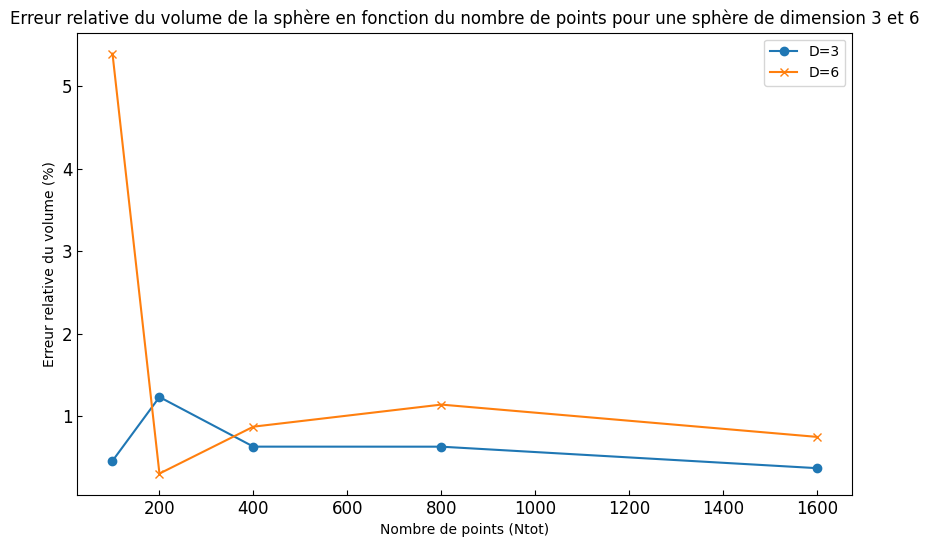

In [24]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))

plt.plot(Ntot_val, err_rel[0], marker='o')
plt.plot(Ntot_val, err_rel[1], marker='x')
plt.legend(['D=3', 'D=6'])
plt.xscale('linear')
plt.yscale('linear')
plt.xlabel('Nombre de points (Ntot)')
plt.ylabel('Erreur relative du volume (%)')   
plt.title('Erreur relative du volume de la sphère en fonction du nombre de points pour une sphère de dimension 3 et 6')
plt.tick_params(axis='both',direction='in', which='both', labelsize=12)
plt.show()

### Réponse c):
*(Ajoutez votre réponse ici)*

**d) [2 pts]** Déterminer le comportement de l'erreur relative en calculant l'exposant $p$ tel que :

$$
E = O(N_{tot}^p)
$$
pour chacune des deux $N$-sphères.

In [27]:

def estimate_coef(x, y):
    # number of observations/points
    n = np.size(x)

    # mean of x and y vector
    m_x = np.mean(x)
    m_y = np.mean(y)

    # calculating cross-deviation and deviation about x
    SS_xy = np.sum(y*x) - n*m_y*m_x
    SS_xx = np.sum(x*x) - n*m_x*m_x

    # calculating regression coefficients
    b_1 = SS_xy / SS_xx
    b_0 = m_y - b_1*m_x

    return (b_0, b_1)

(logc,p)= estimate_coef(np.log(Ntot_val), np.log(err_rel[0]))
(logc2,p2)= estimate_coef(np.log(Ntot_val), np.log(err_rel[1]))
print("Estimation de l'ordre de convergence pour D=3: p = {}".format(p))
print("Estimation de l'ordre de convergence pour D=6: p = {}".format(p2))
# p,intercept= np.polyfit(np.log(Ntot_val), np.log(err_rel[0]), 1)
# p2,intercept2= np.polyfit(np.log(Ntot_val), np.log(err_rel[1]), 1)
# print("Estimation de l'ordre de convergence pour D=3: p = {}".format(p))
# print("Estimation de l'ordre de convergence pour D=6: p = {}".format(p2))

Estimation de l'ordre de convergence pour D=3: p = -0.158512240724883
Estimation de l'ordre de convergence pour D=6: p = -0.37907935812797267


### Réponse d):
*(Ajoutez votre réponse ici)*

**e) [4 pts]** Discuter des points suivants :
* Comment les valeurs de $p$ calculées se comparent-t-elle aux valeurs théoriques attendues ?
* La précision des résultats obtenus est-elle la même pour la 3-sphère et pour la 6-sphère ?
* Comment l'incertitude relative calculée en (b) se compare-t-elle à l'erreur relative ?

### Réponse e):
*(Ajoutez votre réponse ici)*